<a href="https://colab.research.google.com/github/aliabusohiban/Customer-Segmentation-using-KMeans-Clustering/blob/main/Customer_Segmentation_using_KMeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛍️ Customer Segmentation using RFM & KMeans Clustering

**Business Context:**  
As an online retail owner, we want to segment customers based on their purchasing behavior to deliver personalized and effective marketing campaigns — improving retention and revenue.

**Features used:**
- **Recency** – How recently did the customer make a purchase?
- **Frequency** – How often do they purchase?
- **MonetaryValue** – How much do they spend in total?


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## 2. Load the Data

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1NLH5eSvxApbVTpJ5zbTHoiCWLZUlfQA-')
print('Shape:', df.shape)
df.head(10)

Shape: (850, 10)


,Unnamed: 0,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,4,5,47,1,31,253,9.308,8.908,0.0,7.2
5,5,6,40,1,23,81,0.998,7.831,NaN,10.9
6,6,7,38,2,4,56,0.442,0.454,0.0,1.6
7,7,8,42,3,0,64,0.279,3.945,0.0,6.6
8,8,9,26,1,5,18,0.575,2.215,NaN,15.5
9,9,10,47,3,23,115,0.653,3.947,0.0,4.0


## 3. Explore & Clean the Data

In [ ]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       850 non-null    int64  
 1   Customer Id      850 non-null    int64  
 2   Age              850 non-null    int64  
 3   Edu              850 non-null    int64  
 4   Years Employed   850 non-null    int64  
 5   Income           850 non-null    int64  
 6   Card Debt        850 non-null    float64
 7   Other Debt       850 non-null    float64
 8   Defaulted        700 non-null    float64
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(6)
memory usage: 66.5 KB


In [ ]:
df= df.drop(columns= 'Unnamed: 0')
df = df.set_index('Customer Id')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 850 entries, 1 to 850
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              850 non-null    int64  
 1   Edu              850 non-null    int64  
 2   Years Employed   850 non-null    int64  
 3   Income           850 non-null    int64  
 4   Card Debt        850 non-null    float64
 5   Other Debt       850 non-null    float64
 6   Defaulted        700 non-null    float64
 7   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 59.8 KB


In [ ]:
# Check for duplicates
print('Duplicated rows:', df.duplicated().sum())

# Check for missing values
print('\nMissing values per column:')
print(df.isna().sum())

Duplicated rows: 0

Missing values per column:
Age                  0
Edu                  0
Years Employed       0
Income               0
Card Debt            0
Other Debt           0
Defaulted          150
DebtIncomeRatio      0
dtype: int64


In [ ]:
# Summary statistics
df.describe()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000,850.000000
mean,35.029412,1.710588,8.565882,46.675294,1.576820,3.078773,0.261429,10.171647
std,8.041432,0.927784,6.777884,38.543054,2.125843,3.398799,0.439727,6.719441
min,20.000000,1.000000,0.000000,13.000000,0.012000,0.046000,0.000000,0.100000
25%,29.000000,1.000000,3.000000,24.000000,0.382500,1.045750,0.000000,5.100000
50%,34.000000,1.000000,7.000000,35.000000,0.885000,2.003000,0.000000,8.700000
75%,41.000000,2.000000,13.000000,55.750000,1.898500,3.903250,1.000000,13.800000
max,56.000000,5.000000,33.000000,446.000000,20.561000,35.197000,1.000000,41.300000


In [33]:
# Keep only RFM features for clustering (drop CustomerID if present)
dfk = df.copy()

# Drop rows with missing values in RFM columns
dfk.dropna(inplace=True)
print('RFM data shape:', dfk.shape)
dfk.head()

RFM data shape: (700, 8)


,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Customer Id,,,,,,,,
1,41,2,6,19,0.124,1.073,0.0,6.3
2,47,1,26,100,4.582,8.218,0.0,12.8
3,33,2,10,57,6.111,5.802,1.0,20.9
4,29,2,4,19,0.681,0.516,0.0,6.3
5,47,1,31,253,9.308,8.908,0.0,7.2


## 4. Scale the Data

KMeans is a distance-based algorithm, so scaling is **essential** to prevent features with large ranges from dominating the distance calculations.

In [41]:
scaler = StandardScaler()
dfk_scaled = scaler.fit_transform(dfk)

# Keep as DataFrame for readability
dfk_scaled_df = pd.DataFrame(dfk_scaled, columns=dfk.columns)
dfk_scaled_df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0.768304,0.298793,-0.359007,-0.723102,-0.675699,-0.604284,-0.594950,-0.580528
1,1.519090,-0.779325,2.647029,1.478707,1.431421,1.570620,-0.594950,0.372222
2,-0.232744,0.298793,0.242201,0.309845,2.154119,0.835201,1.680814,1.559495
3,-0.733267,0.298793,-0.659610,-0.723102,-0.412427,-0.773833,-0.594950,-0.580528
4,1.519090,-0.779325,3.398538,5.637681,3.665215,1.780653,-0.594950,-0.448609


## 5. Find the Optimal Number of Clusters

We use **two methods**:
- **Elbow Method** – looks for the point where adding more clusters gives diminishing returns in inertia.
- **Silhouette Score** – measures how well each point fits its cluster (higher = better separation).

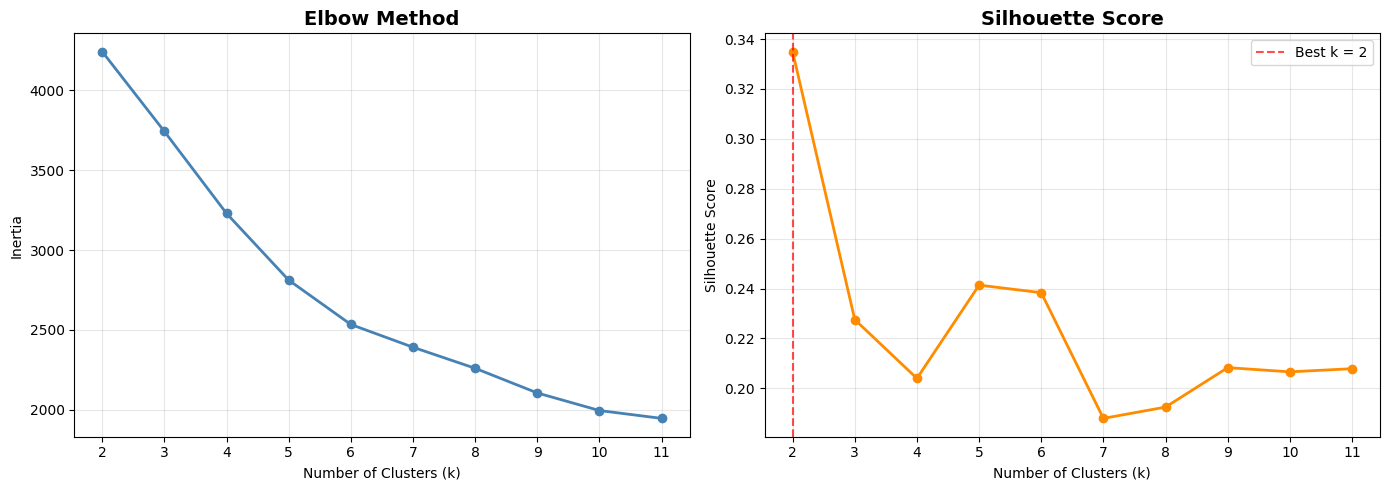


Best k by Silhouette Score: 2 (score = 0.3350)


In [42]:
ks = range(2, 12)
inertias = []
silhouette_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(dfk_scaled_df)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(dfk_scaled_df, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
axes[0].plot(ks, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(ks))
axes[0].grid(True, alpha=0.3)

# Silhouette Score Plot
axes[1].plot(ks, silhouette_scores, marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(ks))
axes[1].grid(True, alpha=0.3)

# Highlight best k on silhouette plot
best_k = ks[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nBest k by Silhouette Score: {best_k} (score = {max(silhouette_scores):.4f})')

## 6. Fit the Final KMeans Model (k = 5)

Based on the plots:
- The **Silhouette Score peaks at k=5** (~0.62), the highest score across all tested values — confirming best cluster separation.
- The **Elbow curve** shows the slope flattening noticeably starting at k=5, after which inertia reduction becomes marginal.

Both methods agree → we proceed with **k = 5**.

In [43]:
OPTIMAL_K = 3

kmeans_final = KMeans(n_clusters=OPTIMAL_K, n_init='auto', random_state=42)
kmeans_final.fit(dfk_scaled_df)

# Assign cluster labels back to the original (unscaled) RFM dataframe
dfk['cluster'] = kmeans_final.labels_

print('Cluster distribution:')
print(dfk['cluster'].value_counts().sort_index())
dfk.head(10)

Cluster distribution:
cluster
0    187
1    412
2    101
Name: count, dtype: int64


,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,cluster
Customer Id,,,,,,,,,
1,41,2,6,19,0.124,1.073,0.0,6.3,1
2,47,1,26,100,4.582,8.218,0.0,12.8,0
3,33,2,10,57,6.111,5.802,1.0,20.9,2
4,29,2,4,19,0.681,0.516,0.0,6.3,1
5,47,1,31,253,9.308,8.908,0.0,7.2,0
7,38,2,4,56,0.442,0.454,0.0,1.6,1
8,42,3,0,64,0.279,3.945,0.0,6.6,1
10,47,3,23,115,0.653,3.947,0.0,4.0,0
11,44,3,8,88,0.285,5.083,1.0,6.1,0


## 7. Explanatory Analysis of Each Cluster

We compute the **mean RFM values per cluster** to understand the characteristics of each group.

In [45]:
# Mean values per cluster
cluster_summary = dfk.groupby('cluster', as_index=False).mean().round(2)
cluster_summary['size'] = dfk.groupby('cluster').size().values
cluster_summary

,cluster,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,size
0,0,42.12,1.59,15.62,70.96,1.74,3.70,0.04,8.26,187
1,1,30.87,1.67,4.73,28.51,0.72,1.58,0.26,8.56,412
2,2,37.69,2.16,9.94,68.39,4.60,7.88,0.65,20.87,101


### Visualize Cluster Means for Each RFM Feature

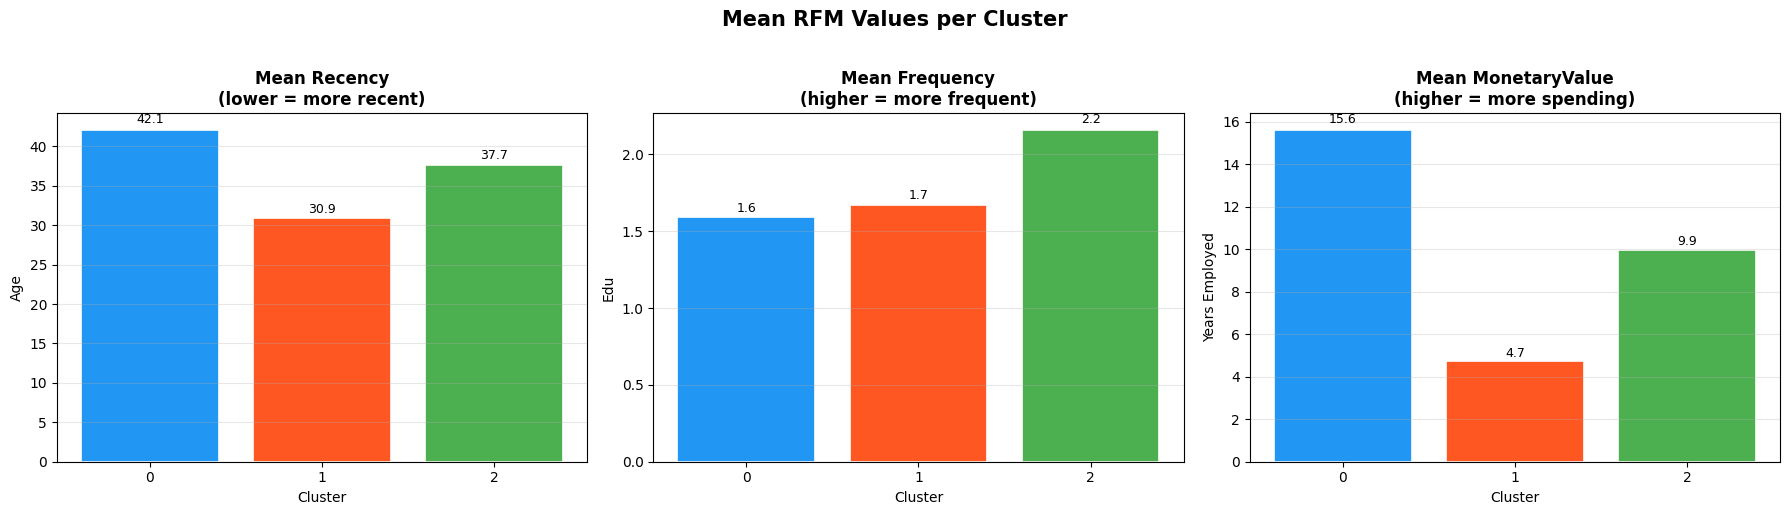

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']

features = dfk.columns
titles = [
    'Mean Recency\n(lower = more recent)',
    'Mean Frequency\n(higher = more frequent)',
    'Mean MonetaryValue\n(higher = more spending)'
]

for i, (feat, title) in enumerate(zip(features, titles)):
    bars = axes[i].bar(
        cluster_summary['cluster'],
        cluster_summary[feat],
        color=colors,
        edgecolor='white',
        linewidth=1.2
    )
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat)
    axes[i].set_xticks(cluster_summary['cluster'])
    axes[i].grid(axis='y', alpha=0.3)
    # Add value labels on bars
    for bar in bars:
        h = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2.,
            h * 1.01,
            f'{h:.1f}',
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Mean RFM Values per Cluster', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_rfm_bars.png', dpi=150, bbox_inches='tight')
plt.show()

### Cluster Size Distribution

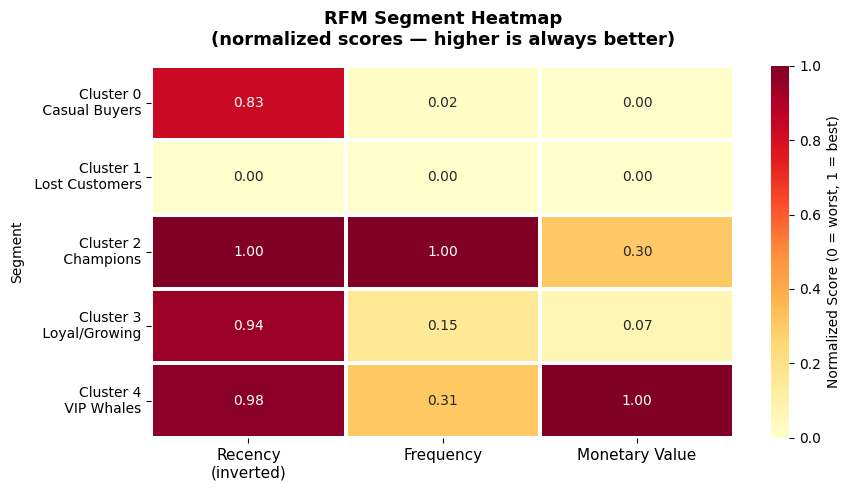

In [ ]:
import seaborn as sns

# Normalize each RFM column to 0-1 for fair comparison
# Recency is inverted: lower recency = better
heatmap_data = cluster_summary[['cluster', 'Recency', 'Frequency', 'MonetaryValue']].copy()
heatmap_data['Recency'] = 1 - (heatmap_data['Recency'] - heatmap_data['Recency'].min()) / (heatmap_data['Recency'].max() - heatmap_data['Recency'].min())
heatmap_data['Frequency'] = (heatmap_data['Frequency'] - heatmap_data['Frequency'].min()) / (heatmap_data['Frequency'].max() - heatmap_data['Frequency'].min())
heatmap_data['MonetaryValue'] = (heatmap_data['MonetaryValue'] - heatmap_data['MonetaryValue'].min()) / (heatmap_data['MonetaryValue'].max() - heatmap_data['MonetaryValue'].min())

segment_labels = {
    0: 'Cluster 0\n Casual Buyers',
    1: 'Cluster 1\n Lost Customers',
    2: 'Cluster 2\n Champions',
    3: 'Cluster 3\n Loyal/Growing',
    4: 'Cluster 4\n VIP Whales'
}
heatmap_data['Segment'] = heatmap_data['cluster'].map(segment_labels)
heatmap_data = heatmap_data.set_index('Segment')[['Recency', 'Frequency', 'MonetaryValue']]
heatmap_data.columns = ['Recency\n(inverted)', 'Frequency', 'Monetary Value']

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=1.5,
    linecolor='white',
    vmin=0, vmax=1,
    cbar_kws={'label': 'Normalized Score (0 = worst, 1 = best)'}
)
plt.title('RFM Segment Heatmap\n(normalized scores — higher is always better)', fontsize=13, fontweight='bold', pad=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.savefig('rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Radar Chart: RFM Profile per Cluster

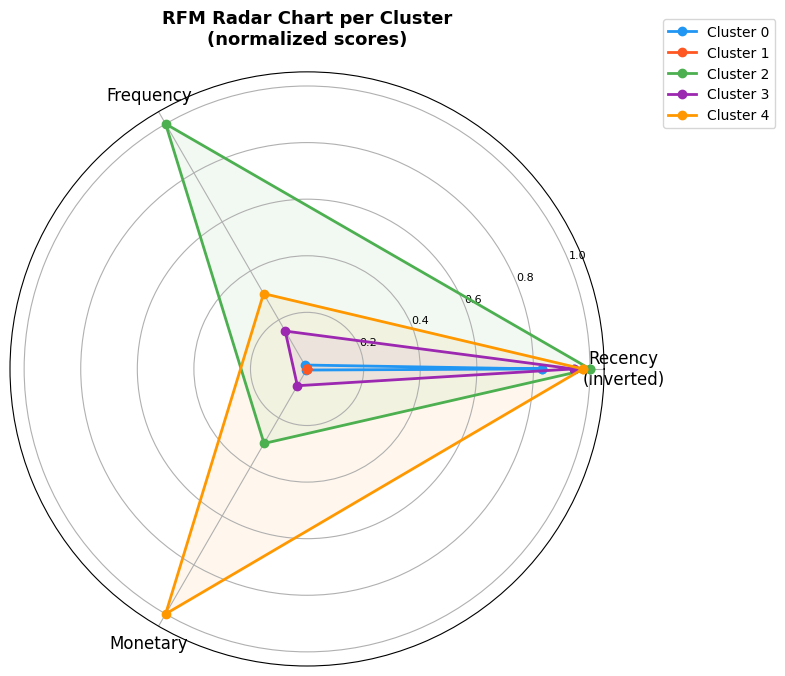

In [ ]:
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path

# Normalize each feature to [0, 1] for radar chart
radar_data = cluster_summary[['cluster', 'Recency', 'Frequency', 'MonetaryValue']].copy()

# For Recency: invert so that lower recency (more recent) = higher score
radar_data['Recency_score'] = 1 - (
    (radar_data['Recency'] - radar_data['Recency'].min()) /
    (radar_data['Recency'].max() - radar_data['Recency'].min())
)
for col in ['Frequency', 'MonetaryValue']:
    mn, mx = radar_data[col].min(), radar_data[col].max()
    radar_data[f'{col}_score'] = (radar_data[col] - mn) / (mx - mn) if mx != mn else 0

categories = ['Recency\n(inverted)', 'Frequency', 'Monetary']
score_cols = ['Recency_score', 'Frequency_score', 'MonetaryValue_score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for idx, row in radar_data.iterrows():
    values = row[score_cols].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {int(row["cluster"])}', color=colors[idx])
    ax.fill(angles, values, alpha=0.07, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('RFM Radar Chart per Cluster\n(normalized scores)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Segment Naming & Interpretation

Based on the bar charts, pie chart, and radar chart:

| Cluster | Segment Name | Recency | Frequency | Monetary | Size | Profile |
|---------|-------------|---------|-----------|----------|------|---------|
| 0 | 😴 Casual / Passive Buyers | Medium (43.8) | Low (3.7) | Very Low (1,359) | 70.5% | Majority of customers. Shop occasionally, low spend, not very engaged. |
| 1 | 💤 Lost / Churned Customers | High (248.5) | Very Low (1.6) | Minimal (480) | 24.5% | Haven't purchased in a long time. Serious churn risk. |
| 2 | 🏆 Champions (Frequent) | Very Recent (1.5) | Very High (135.8) | High (58,381) | ~0.1% | Buy extremely often and very recently. High-value repeat customers. |
| 3 | 🌟 Loyal / Growing Customers | Recent (15.7) | Good (22.3) | Good (13,534) | 4.7% | Recent, engaged, spending well. Rising loyal customers. |
| 4 | 💎 VIP / Whale Customers | Very Recent (7.7) | High (42.8) | Highest (190,864) | ~0.1% | Spend by far the most. Extremely valuable even though tiny in number. |


# RFM Marketing Strategy

---

## Cluster 0 — Casual Buyers
**Goal:** Convert them into repeat buyers.

**Actions:**
- If no purchase in 14 days → send automated coupon (15% off)
- If no purchase in 30 days → send "new arrivals" notification
- After 5 purchases → automatically move to Cluster 3 treatment

**Success Metric:** 20% of Cluster 0 reaches 5+ purchases within 3 months

---

## Cluster 1 — Lost Customers
**Goal:** Win back a portion, retire the rest.

**Actions:**
- Attempt 1: "We miss you" message + 25% off coupon
- Attempt 2 (after 2 weeks): expiring offer (48-hour countdown)
- Attempt 3 (after 2 more weeks): final short survey ("why did you leave?")
- No response after 3 attempts → remove from all active campaigns

**Success Metric:** 10% reactivation rate after the 3-attempt sequence

---

## Cluster 2 — Champions
**Goal:** Keep them active and increase basket size.

**Actions:**
- Enroll in VIP loyalty tier with exclusive perks
- Early access to new products before public launch
- Monthly personalized recommendation based on purchase history
- Invite to referral program with real rewards

**Success Metric:** Zero drop in purchase frequency over 3 months

---

## Cluster 3 — Loyal/Growing
**Goal:** Push them toward Champion level.

**Actions:**
- Tiered rewards: unlock better perks every 10 purchases
- Cross-sell based on what they already buy
- Milestone messages: "You've made 20 orders — here's a gift"
- Track monthly: is frequency and basket size increasing?

**Success Metric:** 25% of Cluster 3 reaches Champion-level activity within 6 months

---

## Cluster 4 — VIP Whales
**Goal:** Protect at all costs.

**Actions:**
- Assign a dedicated account manager for each customer
- Physical gifts on occasions — not coupons
- Flag immediately if no purchase in 14 days → personal follow-up call
- Offer early wholesale access

**Success Metric:** 0 churn. Any drop in engagement triggers immediate action.

---

## Priority Order

| Priority | Cluster | Why |
|----------|---------|-----|
| 1st | Cluster 4 | Losing one = losing massive revenue |
| 2nd | Cluster 2 | Highest frequency, must stay active |
| 3rd | Cluster 3 | High conversion potential |
| 4th | Cluster 0 | Largest group, automate everything |
| 5th | Cluster 1 | Low ROI, minimal effort only |

---

## Key Rule

Clusters 4 and 2 get personal attention.
Clusters 0 and 1 get automated systems.
Cluster 3 gets a mix of both.

In [ ]:
summary_final = rfm.groupby('segment').agg(
    Count=('cluster', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_MonetaryValue=('MonetaryValue', 'mean')
).round(1).sort_values('Avg_MonetaryValue', ascending=False)
summary_final['Pct_of_Customers'] = (summary_final['Count'] / summary_final['Count'].sum() * 100).round(1)
summary_final

,Count,Avg_Recency,Avg_Frequency,Avg_MonetaryValue,Pct_of_Customers
segment,,,,,
VIP / Whale Customers,6,7.7,42.8,190863.5,0.1
Champions (Frequent),6,1.5,135.8,58381.1,0.1
Loyal / Growing Customers,203,15.7,22.3,13534.0,4.7
Casual / Passive Buyers,3060,43.8,3.7,1358.8,70.5
Lost / Churned Customers,1063,248.5,1.6,480.4,24.5
